In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [56]:
import gc

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

2056.642578125 MB


In [57]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),( 0.5, 0.5, 0.5))
])

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),( 0.5, 0.5, 0.5))
])

train_dataset = datasets.OxfordIIITPet(
    root='C:\MLbrat\andre\MoneyApp\datasets\data_animal',
    split='trainval',   # train + validation вместе
    download=True,
    transform=transform
)

test_dataset = datasets.OxfordIIITPet(
    root='C:\MLbrat\andre\MoneyApp\datasets\data_animal',
    split='test',
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_ds, val_ds = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # фиксируем split
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

In [59]:
latent_dim = 17
lr = 0.0002
beta1 = 0.5
beta2= 0.999
num_epoch = 10

In [60]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.ReLU(),
            nn.Unflatten(1, (128, 8, 8)),
            
            nn.Upsample(scale_factor=2), # -> 16x16
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.78),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2), # -> 32x32
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.78),
            nn.ReLU(),
            
            # --- ДОБАВЛЯЕМ НОВЫЕ СЛОИ ДЛЯ УВЕЛИЧЕНИЯ ---
            nn.Upsample(scale_factor=2), # -> 64x64
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32, momentum=0.78),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2), # -> 128x128
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16, momentum=0.78),
            nn.ReLU(),
            # ------------------------------------------

            # Финальный слой выдает 3 канала (RGB)
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img

In [61]:

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            # Вход: 3 канала, размер 128x128
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # -> 64x64
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            # Слой 2
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> 32x32
            # Убрали nn.ZeroPad2d, чтобы картинка ровно делилась на 2
            nn.BatchNorm2d(64, momentum=0.82),
            nn.LeakyReLU(0.25),
            nn.Dropout(0.25),

            # Слой 3
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # -> 16x16
            nn.BatchNorm2d(128, momentum=0.82),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),

            # Слой 4 (Изменили stride=1 на stride=2 для дополнительного сжатия)
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), # -> 8x8
            nn.BatchNorm2d(256, momentum=0.8),
            nn.LeakyReLU(0.25),
            nn.Dropout(0.25),

            nn.Flatten(),
            
            # После 4 сжатий в 2 раза размер картинки 128x128 превращается в 8x8.
            # 256 каналов * 8 высота * 8 ширина = 16384
            nn.Linear(256 * 8 * 8, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

In [62]:
generator = Generator(latent_dim).to(device)
discrem = Discriminator().to(device)

adversarial_loss = nn.BCELoss()

optimizer_g = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))

optimizer_d = optim.Adam(discrem.parameters(),lr=lr, betas =(beta1,beta2))

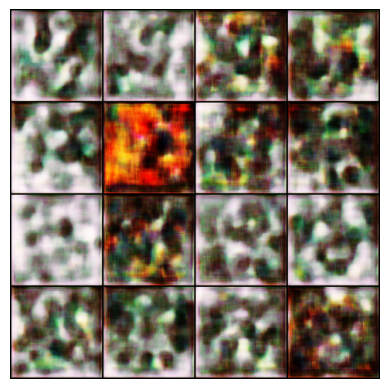

In [63]:
for epoch in range(num_epoch):
    for i, batch in enumerate(dataloader):
       
        real_images = batch[0].to(device) 
       
        valid = torch.ones(real_images.size(0), 1, device=device)
        fake = torch.zeros(real_images.size(0), 1, device=device)
       
        real_images = real_images.to(device)

        optimizer_d.zero_grad()
       
        z = torch.randn(real_images.size(0), latent_dim, device=device)
      
        fake_images = generator(z)

        real_loss = adversarial_loss(discrem\
                                     (real_images), valid)
        fake_loss = adversarial_loss(discrem\
                                     (fake_images.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
    
        d_loss.backward()
        optimizer_d.step()

        optimizer_g.zero_grad()
      
        gen_images = generator(z)
        
        g_loss = adversarial_loss(discrem(gen_images), valid)
        g_loss.backward()
        optimizer_g.step()
       
        if (i + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epoch}]\
                        Batch {i+1}/{len(dataloader)} "
                f"Discriminator Loss: {d_loss.item():.4f} "
                f"Generator Loss: {g_loss.item():.4f}"
            )
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z = torch.randn(16, latent_dim, device=device)
            generated = generator(z).detach().cpu()
            grid = torchvision.utils.make_grid(generated,\
                                        nrow=4, normalize=True)
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.axis("off")
            plt.show()

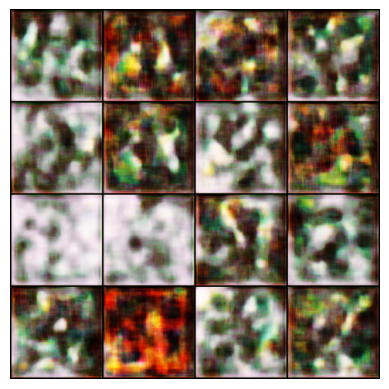

In [64]:
with torch.no_grad():
            z = torch.randn(16, latent_dim, device=device)
            generated = generator(z).detach().cpu()
            grid = torchvision.utils.make_grid(generated,\
                                        nrow=4, normalize=True)
            plt.imshow(np.transpose(grid, (1, 2, 0)))
            plt.axis("off")
            plt.show()

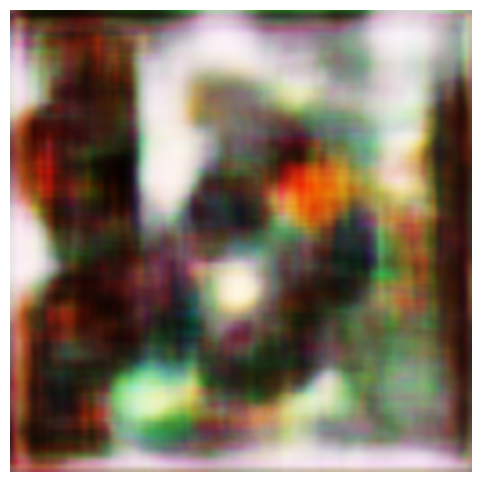

In [65]:
import matplotlib.pyplot as plt
import torchvision
import torch
import numpy as np

with torch.no_grad():
    # 1. Генерируем вектор шума только для 1 изображения (вместо 16)
    z = torch.randn(1, latent_dim, device=device)
    
    # 2. Пропускаем через генератор
    generated = generator(z).detach().cpu()
    
    # 3. Нормализуем картинку (make_grid удобно использовать даже для 1 фото, 
    # так как он автоматически переводит значения из [-1, 1] в [0, 1] благодаря normalize=True)
    img = torchvision.utils.make_grid(generated, normalize=True)
    
    # 4. Увеличиваем размер окна вывода (например, 6x6 дюймов)
    plt.figure(figsize=(6, 6))
    
    # 5. Выводим картинку со сглаживанием (interpolation='bicubic')
    # Это сделает 32x32 картинку визуально более приятной при увеличении
    plt.imshow(np.transpose(img, (1, 2, 0)), interpolation='bicubic')
    
    plt.axis("off")
    plt.show()